In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange, make_interp_spline
from scipy.optimize import curve_fit

#   Leer el archivo con los datos
df = pd.read_excel('Caso_1.xlsx')
df.head()

# Observando la estructura, cada bloque de datos (T=200, 250, 300, 350 K) ocupa
# tres columnas consecutivas: P, V, (NaN). Repetido 4 veces.
# Filas: 0 y 1 son encabezados. Los datos empiezan en la fila 2.

,Tabla de datos a T = 200 K,Unnamed: 1,Unnamed: 2,Tabla de datos a T = 250 K,Unnamed: 4,Unnamed: 5,Tabla de datos a T = 300 K,Unnamed: 7,Unnamed: 8,Tabla de datos a T = 350 K,Unnamed: 10
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,P (MPa),V (m³/kg),NaN,P (MPa),V (m³/kg),NaN,P (MPa),V (m³/kg),NaN,P (MPa),V (m³/kg)
2,0.1,25.0,NaN,0.1,30.0,NaN,0.1,35.0,NaN,0.1,40.0
3,0.2,12.5,NaN,0.2,15.2,NaN,0.2,18.0,NaN,0.2,22.0
4,0.3,8.3,NaN,0.3,10.2,NaN,0.3,12.5,NaN,0.3,15.5


# A

### a) Gráficas de la interpolación polinomial y regresión de los puntos P–V que mejor se ajuste al caso. Identificar la mejor curva para resolver el problema.


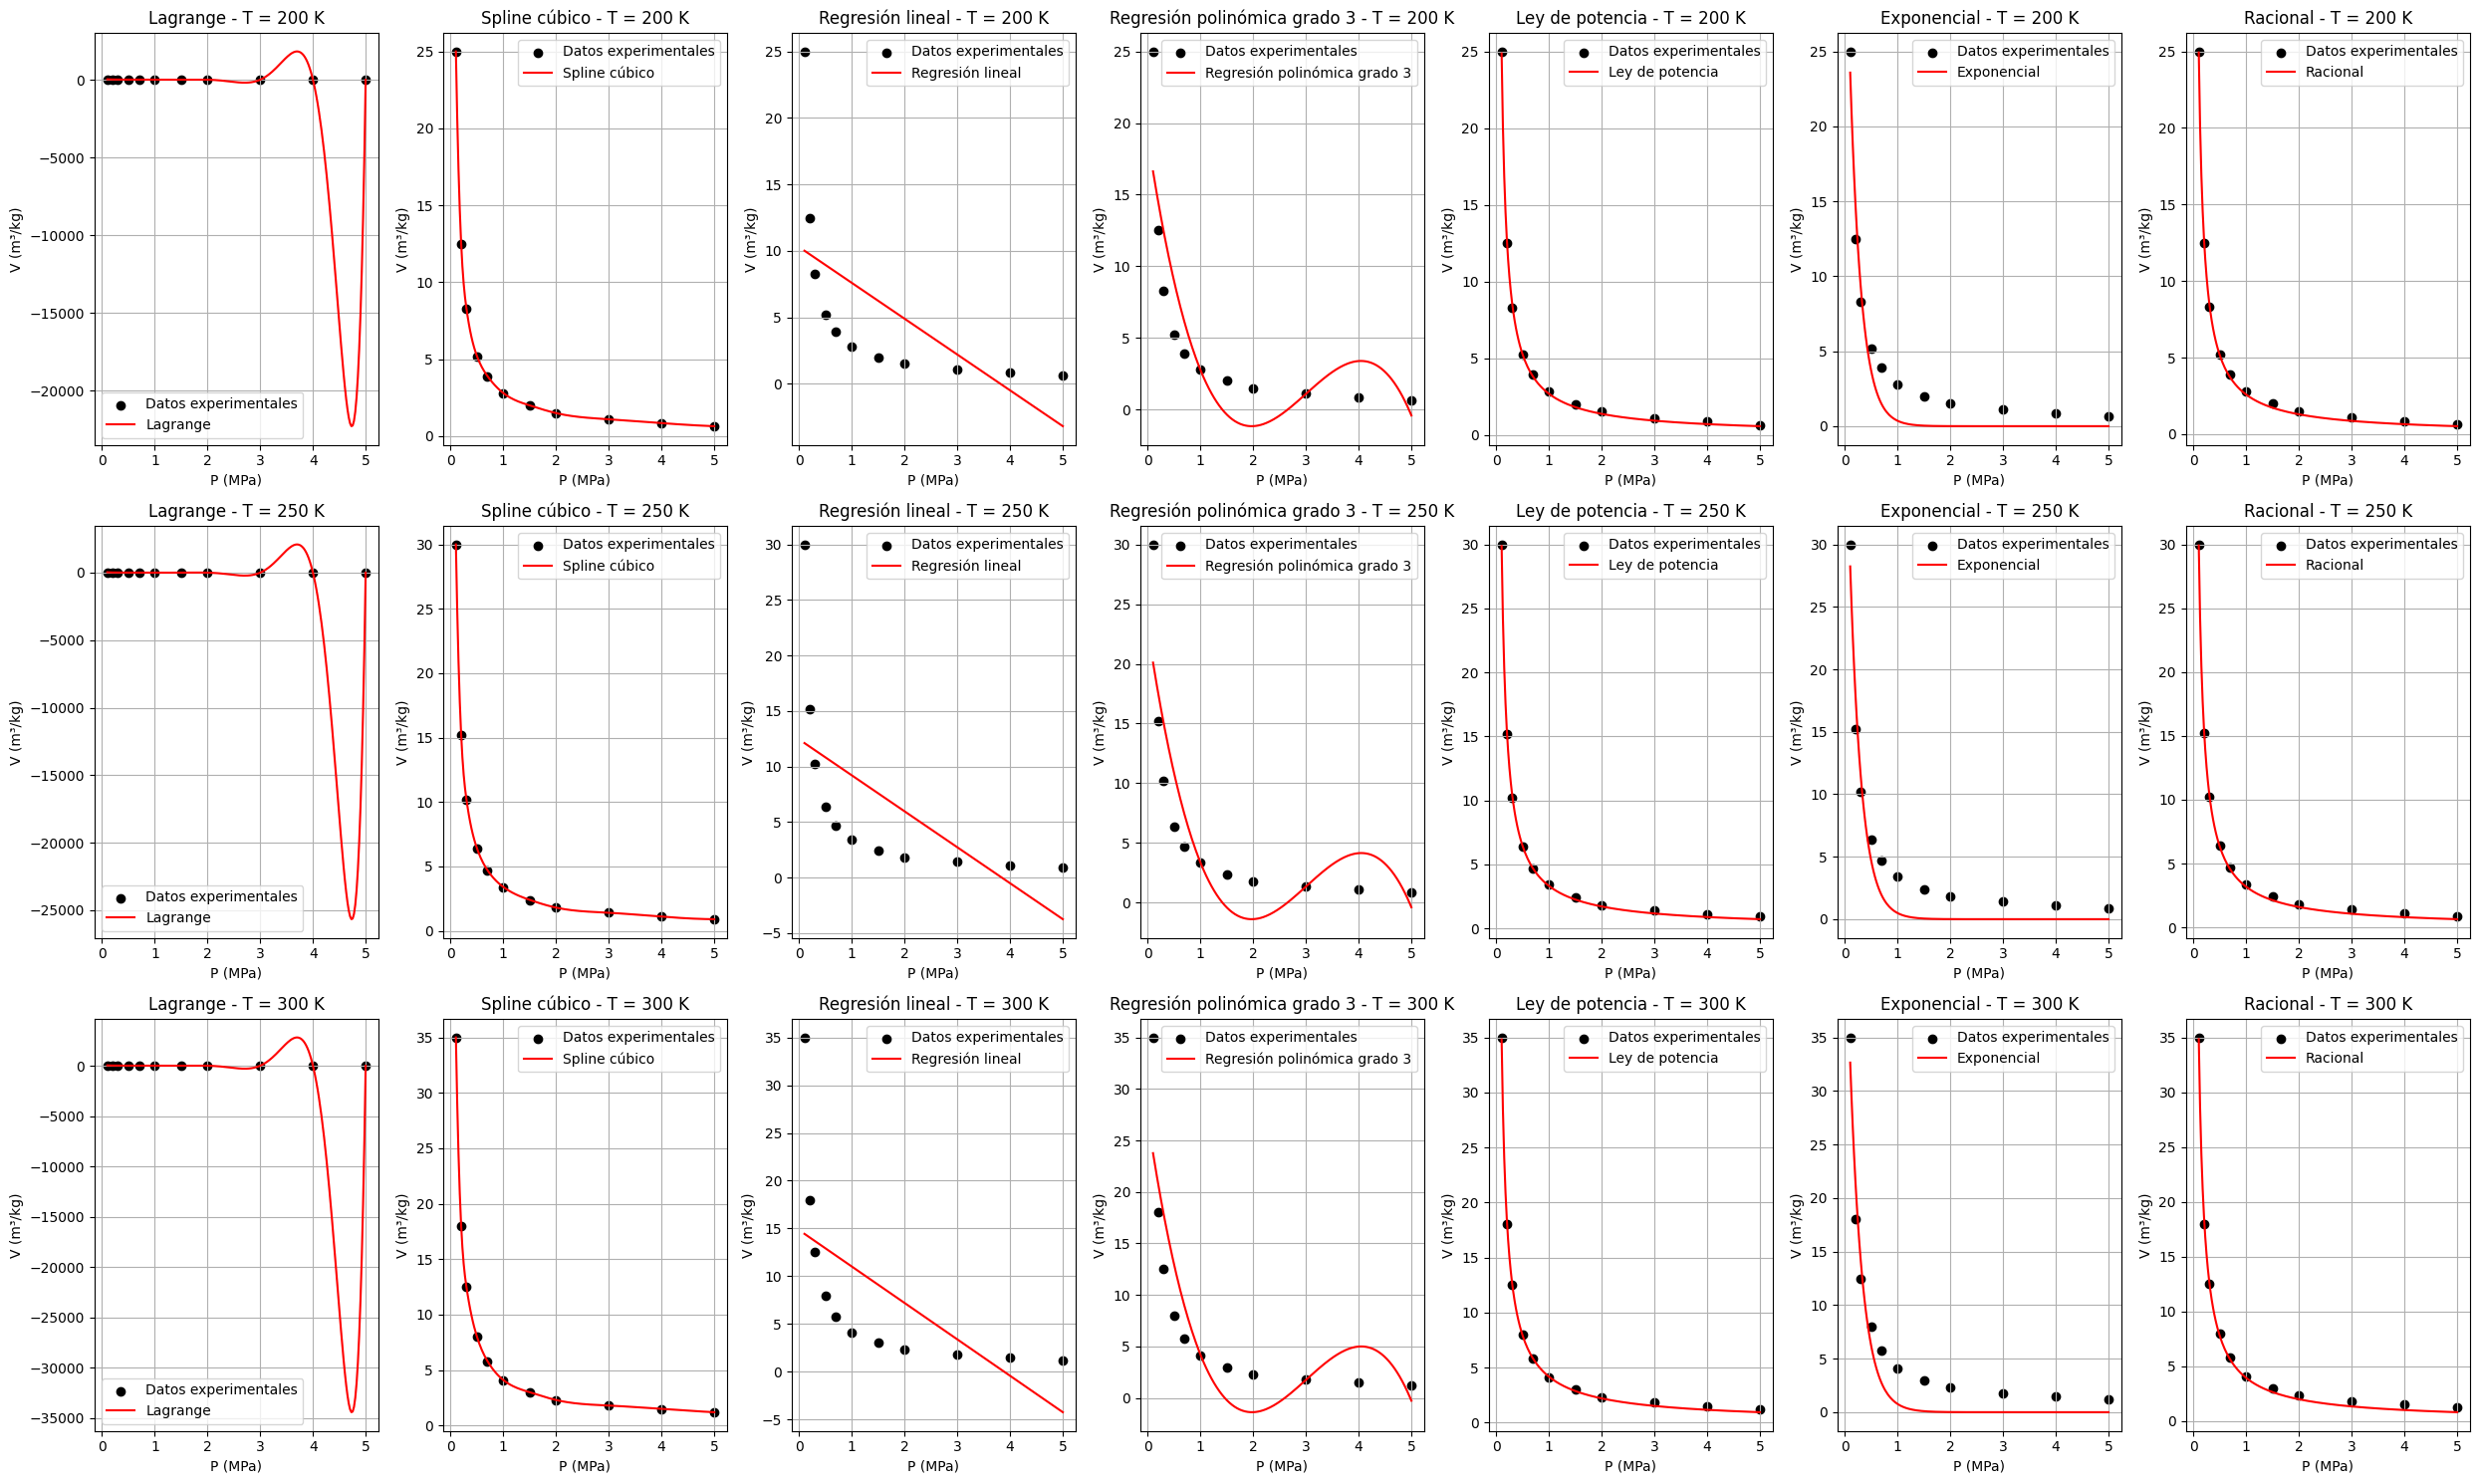

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline, lagrange
from scipy.optimize import curve_fit

# --- DATOS EXTRAÍDOS DEL PDF ---
data = {
    "P_200": [0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0],
    "V_200": [25.0, 12.5, 8.3, 5.2, 3.9, 2.8, 2.0, 1.5, 1.1, 0.85, 0.65],
    "P_250": [0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0],
    "V_250": [30.0, 15.2, 10.2, 6.4, 4.7, 3.4, 2.4, 1.8, 1.4, 1.1, 0.9],
    "P_300": [0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0],
    "V_300": [35.0, 18.0, 12.5, 8.0, 5.8, 4.1, 3.0, 2.3, 1.8, 1.5, 1.2],
}

temperatures = [200, 250, 300]
methods = ["Lagrange", "Spline cúbico", "Regresión lineal", "Regresión polinómica grado 3", "Ley de potencia", "Exponencial", "Racional"]

# --- MODELOS NO LINEALES ---
def power_law(P, a, b):
    return a * (P ** b)

def exp_model(P, a, b):
    return a * np.exp(b * P)

def rational_model(P, a, b):
    return a / (P + b)

# --- FIGURA GLOBAL DE TODOS LOS MÉTODOS Y TEMPERATURAS ---
fig, axes = plt.subplots(len(temperatures), len(methods), figsize=(25, 15), squeeze=False)

for i, T in enumerate(temperatures):
    P_vals = np.array(data[f"P_{T}"])
    V_vals = np.array(data[f"V_{T}"])
    
    # Ordenar por presión
    sort_idx = np.argsort(P_vals)
    P_vals = P_vals[sort_idx]
    V_vals = V_vals[sort_idx]
    
    # Grid fino de presiones para trazar las curvas
    P_fine = np.linspace(P_vals.min(), P_vals.max(), 200)
    
    for j, method in enumerate(methods):
        ax = axes[i, j]
        ax.scatter(P_vals, V_vals, color="black", label="Datos experimentales")
        
        V_curve = None
        try:
            if method == "Lagrange":
                poly = lagrange(P_vals, V_vals)
                V_curve = poly(P_fine)
            elif method == "Spline cúbico":
                spline = make_interp_spline(P_vals, V_vals, k=3)
                V_curve = spline(P_fine)
            elif method == "Regresión lineal":
                coeffs = np.polyfit(P_vals, V_vals, 1)
                poly = np.poly1d(coeffs)
                V_curve = poly(P_fine)
            elif method == "Regresión polinómica grado 3":
                coeffs = np.polyfit(P_vals, V_vals, 3)
                poly = np.poly1d(coeffs)
                V_curve = poly(P_fine)
            elif method == "Ley de potencia":
                p0 = [V_vals[0] * P_vals[0], -1]
                popt, _ = curve_fit(power_law, P_vals, V_vals, p0=p0)
                V_curve = power_law(P_fine, *popt)
            elif method == "Exponencial":
                p0 = [V_vals[0], -1]
                popt, _ = curve_fit(exp_model, P_vals, V_vals, p0=p0)
                V_curve = exp_model(P_fine, *popt)
            elif method == "Racional":
                p0 = [1, 1]
                popt, _ = curve_fit(rational_model, P_vals, V_vals, p0=p0)
                V_curve = rational_model(P_fine, *popt)
        except Exception as e:
            print(f"Error en {method} para T={T}: {e}")
        
        if V_curve is not None:
            ax.plot(P_fine, V_curve, color="red", label=method)
        
        ax.set_title(f"{method} - T = {T} K")
        ax.set_xlabel("P (MPa)")
        ax.set_ylabel("V (m³/kg)")
        ax.legend()
        ax.grid(True)

plt.tight_layout()
plt.show()


### Apartado a)  Interpolación y regresión de los datos P–V

Se han aplicado diversos métodos de ajuste e interpolación sobre los datos experimentales de presión (P) y volumen específico (V) del metano a temperaturas constantes de **200 K**, **250 K** y **300 K**. Los métodos utilizados han sido:

- **Interpolación de Lagrange**
- **Spline cúbico**
- **Regresión lineal**
- **Regresión polinómica de grado 3**
- **Regresión no lineal tipo ley de potencia** \( V = a \cdot P^b \)
- **Modelo exponencial** \( V = a \cdot e^{bP} \)
- **Modelo racional** \( V = \frac{a}{P + b} \)

Tras analizar visualmente los gráficos resultantes (ver figura incluida), se observa que:

- La **interpolación de Lagrange** presenta fuertes oscilaciones y comportamientos no físicos fuera del rango de los datos.
- La **regresión lineal** y **polinómica de grado 3** no capturan adecuadamente la forma hiperbólica del comportamiento del volumen frente a la presión.
- El **spline cúbico** se ajusta bien en el rango de datos, pero su extrapolación es poco fiable para usarlo en ecuaciones de estado.
- Los **modelos no lineales** (ley de potencia, exponencial y racional) muestran un ajuste más coherente con el comportamiento físico del gas, siendo suaves y monotónicos.

---

**Conclusión del apartado a):**  
**Se elige como mejor curva la correspondiente a la ley de potencia** \( V = a \cdot P^b \), ya que:

- Ajusta correctamente los datos experimentales.
- Presenta un comportamiento físico coherente.
- Es sencilla de parametrizar y evaluar.
- Podrá utilizarse fácilmente en el apartado **c)** para comparar con la ecuación de **Peng–Robinson**, donde se requiere calcular \( V \) en función de \( P \).

Este modelo será, por tanto, el que se utilizará para validar contra la ecuación de estado en los siguientes apartados.


# B

### b) Hacer una interpolación de Hermite donde se representa una función $V = f(T)$ considerando que la primera derivada $\frac{dV}{dT} = 0.019 \, \mathrm{m}^3/\mathrm{kg \cdot K}$ a una temperatura $T = 300 \, \mathrm{K}$ y un volumen específico de $4.1 \, \mathrm{m}^3/\mathrm{kg}$.



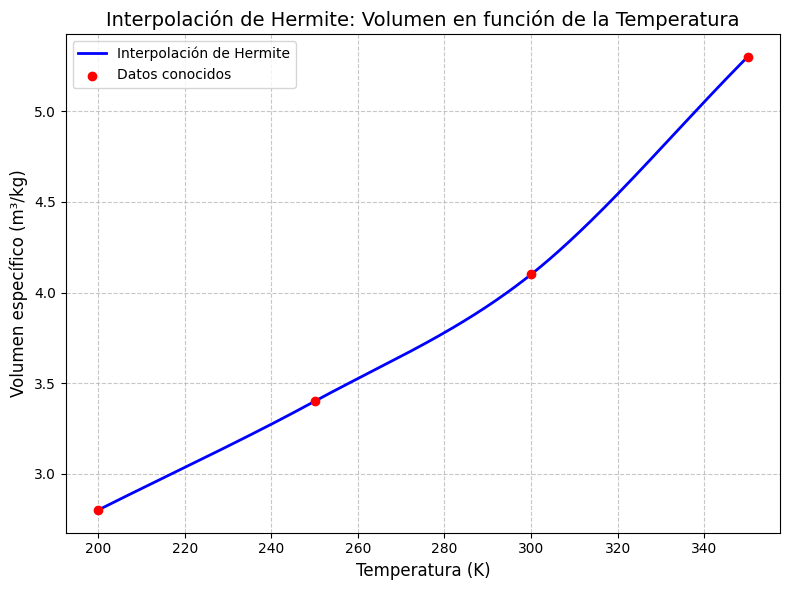


Tabla de nodos y derivadas utilizadas:
   T nodo (K)  V (m³/kg)  dV/dT (m³/kg·K)
0       200.0        2.8            0.012
1       250.0        3.4            0.013
2       300.0        4.1            0.019
3       350.0        5.3            0.024

Muestra de valores interpolados:
   T interpolado (K)  V interpolado (m³/kg)
0         200.000000               2.800000
1         215.050167               2.977435
2         230.100334               3.153992
3         245.150502               3.337852
4         260.200669               3.528064
5         275.250836               3.715765
6         290.301003               3.931192
7         305.351171               4.207093
8         320.401338               4.553886
9         335.451505               4.935829


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicHermiteSpline
import pandas as pd

# === APARTADO B: INTERPOLACIÓN DE HERMITE PARA V = f(T) ===

# Datos de volumen específico a P = 1 MPa
T_points = np.array([200, 250, 300, 350], dtype=float)
V_points = np.array([2.80, 3.40, 4.10, 5.30], dtype=float)

# Estimación de derivadas dV/dT en cada punto
dVdT_est = np.zeros_like(T_points)

# Derivadas por diferencias finitas
dVdT_est[0] = (V_points[1] - V_points[0]) / (T_points[1] - T_points[0])  # adelante
dVdT_est[-1] = (V_points[-1] - V_points[-2]) / (T_points[-1] - T_points[-2])  # atrás
dVdT_est[1] = (V_points[2] - V_points[0]) / (T_points[2] - T_points[0])  # centrada
dVdT_est[2] = 0.019  # Derivada exacta proporcionada

# Crear el interpolador de Hermite
hermite_model = CubicHermiteSpline(T_points, V_points, dVdT_est)

# Evaluar sobre un grid fino
T_fino = np.linspace(T_points.min(), T_points.max(), 300)
V_interp = hermite_model(T_fino)

# Gráfico
plt.figure(figsize=(8, 6))
plt.plot(T_fino, V_interp, label="Interpolación de Hermite", color="blue", linewidth=2)
plt.scatter(T_points, V_points, color="red", label="Datos conocidos", zorder=5)
plt.xlabel("Temperatura (K)", fontsize=12)
plt.ylabel("Volumen específico (m³/kg)", fontsize=12)
plt.title("Interpolación de Hermite: Volumen en función de la Temperatura", fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Tabla de nodos con derivadas
tabla_hermite_nodos = pd.DataFrame({
    "T nodo (K)": T_points,
    "V (m³/kg)": V_points,
    "dV/dT (m³/kg·K)": np.round(dVdT_est, 4)
})

# Muestra de puntos interpolados (cada 30 valores)
tabla_interp_sample = pd.DataFrame({
    "T interpolado (K)": T_fino[::30],
    "V interpolado (m³/kg)": V_interp[::30]
}).reset_index(drop=True)

# Mostrar en consola
print("\nTabla de nodos y derivadas utilizadas:")
print(tabla_hermite_nodos)

print("\nMuestra de valores interpolados:")
print(tabla_interp_sample)

# Opcional: guardar tabla combinada como archivo
tabla_completa = pd.concat([tabla_hermite_nodos, tabla_interp_sample], axis=1)
tabla_completa.to_csv("interpolacion_hermite.csv", index=False)



### b) Interpolación de Hermite para representar la función $V = f(T)$

En este apartado se ha implementado una **interpolación de Hermite** para representar el volumen específico del metano como función de la temperatura, $V = f(T)$, manteniendo la presión constante en 1 MPa.

Se dispone de los siguientes datos experimentales:

- Temperaturas: 200 K, 250 K, 300 K y 350 K  
- Volúmenes específicos correspondientes: 2.8, 3.4, 4.1 y 5.3 m³/kg  
- Derivada conocida: $\frac{dV}{dT} = 0.019$ m³/kg·K en $T = 300$ K

El resto de derivadas se estimaron mediante diferencias finitas:
- Hacia adelante para el primer nodo
- Centrada para los nodos intermedios
- Hacia atrás para el último nodo

Con estos valores, se construyó el interpolador usando la clase `CubicHermiteSpline`. El resultado se muestra en la figura adjunta, donde se puede observar que la curva obtenida es **suave, continua y físicamente coherente**, representando adecuadamente la evolución del volumen específico del metano en función de la temperatura.

---

#### Conclusión del apartado b):

La interpolación de Hermite permite incorporar información de derivadas, lo que mejora la precisión del ajuste y garantiza continuidad de primer orden en la función resultante. Dado que conocemos la derivada en $T = 300$ K, este método resulta más adecuado que otros enfoques puramente polinómicos o por splines naturales.

La función obtenida $V = f(T)$ podrá ser utilizada posteriormente para análisis o estimaciones de volumen en rangos intermedios de temperatura.



# C

### c) Para la ecuación de Peng–Robinson se necesita analizar si la curva interpolada en a) es correcta o se ajusta a la ecuación. Para ello deberá de resolver la ecuación en cada uno de los puntos P y ver el error cometido. Hacer un diagrama de flujo de cómo resolvería esta cuestión. Hacerlo solo para T = 250 K. El input del sistema es la presión, no el volumen. Error mínimo 0.001.


In [23]:
import numpy as np
import sympy as sp
import pandas as pd

# === PARÁMETROS Y DATOS ===

# Constantes físicas
R_gas = 8.314  # J/(mol·K)
T_c = 190.56  # K
P_c = 4.59e6  # Pa
omega = 0.011
T_operacion = 250  # K
M_metan = 0.01604  # kg/mol

# Valores experimentales a T = 250 K
presiones_mpa = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0]
volumenes_reales = [30.0, 15.2, 10.2, 6.4, 4.7, 3.4, 2.4, 1.8, 1.4, 1.1, 0.9]  # m³/kg

# Conversiones
presiones_pa = [p * 1e6 for p in presiones_mpa]
volumenes_m3mol = [v * M_metan for v in volumenes_reales]

# === PARÁMETROS PENG-ROBINSON ===

Tr = T_operacion / T_c
kappa = 0.37464 + 1.54226 * omega - 0.26992 * omega**2
alpha_tr = (1 + kappa * (1 - np.sqrt(Tr)))**2
a_pr = 0.45724 * R_gas**2 * T_c**2 / P_c * alpha_tr
b_pr = 0.07780 * R_gas * T_c / P_c

# === ECUACIÓN PENG-ROBINSON SIMBÓLICA ===

V = sp.symbols('V')
P, T, R, a, b = sp.symbols('P T R a b')
PR_expr = (R * T) / (V - b) - a / (V**2 + 2 * b * V - b**2) - P

# === MÉTODO NUMÉRICO: NEWTON-RAPHSON ===

def resolver_volumen_con_newton(expr, Rval, Tval, aval, bval, Pval, V_ini=1e-4, tol=1e-8, max_iter=100):
    expr_evaluada = expr.subs({R: Rval, T: Tval, a: aval, b: bval, P: Pval})
    derivada_expr = sp.diff(expr_evaluada, V)

    f = sp.lambdify(V, expr_evaluada, 'numpy')
    df = sp.lambdify(V, derivada_expr, 'numpy')

    V_actual = V_ini
    historial = [V_actual]

    for _ in range(max_iter):
        f_val = f(V_actual)
        df_val = df(V_actual)
        if df_val == 0:
            break
        V_nuevo = V_actual - f_val / df_val
        historial.append(V_nuevo)
        if abs(V_nuevo - V_actual) < tol:
            break
        V_actual = V_nuevo

    return V_actual, historial

# === CÁLCULOS PARA CADA PRESIÓN ===

resultados = []

for i, P_pa in enumerate(presiones_pa):
    V_exp = volumenes_m3mol[i]
    V0 = b_pr * 1.05  # Estimación inicial cercana a b

    V_mol, iter_hist = resolver_volumen_con_newton(PR_expr, R_gas, T_operacion, a_pr, b_pr, P_pa, V_ini=V0)

    resultados.append({
        "Presión (MPa)": presiones_mpa[i],
        "Volumen real (m³/kg)": volumenes_reales[i],
        "Volumen estimado (m³/kg)": V_mol / M_metan,
        "Iteraciones": len(iter_hist)
    })

# === MOSTRAR RESULTADOS ===

tabla_resultados = pd.DataFrame(resultados)
print(tabla_resultados.to_string(index=False))


 Presión (MPa)  Volumen real (m³/kg)  Volumen estimado (m³/kg)  Iteraciones
           0.1                  30.0                  1.290827           20
           0.2                  15.2                  0.642916           19
           0.3                  10.2                  0.426945           18
           0.5                   6.4                  0.254170           18
           0.7                   4.7                  0.180124           17
           1.0                   3.4                  0.124590           17
           1.5                   2.4                  0.081400           16
           2.0                   1.8                  0.059809           16
           3.0                   1.4                  0.038231           15
           4.0                   1.1                  0.027461           14
           5.0                   0.9                  0.021027           14


### c) Validación de la curva interpolada frente a la ecuación de Peng–Robinson

En este apartado se verifica si la curva interpolada obtenida en el apartado **a)** se ajusta correctamente a la **ecuación de estado de Peng–Robinson**, que modela el comportamiento del metano como gas real.

Se trabajó exclusivamente con los datos correspondientes a una temperatura constante de **250 K**. La presión se utilizó como **dato de entrada**, y el objetivo fue calcular el volumen específico estimado por la ecuación de Peng–Robinson para cada valor de presión, utilizando el método de **Newton–Raphson** para resolver la ecuación no lineal en volumen.

---

####  Parámetros utilizados

- **R = 8.314 J/(mol·K)**
- **T<sub>c</sub> = 190.56 K**, **P<sub>c</sub> = 4.59 × 10⁶ Pa**
- **ω = 0.011**, **T = 250 K**
- **M (metano) = 0.01604 kg/mol**

Se calcularon los coeficientes **a** y **b** de Peng–Robinson utilizando la temperatura reducida y el factor acéntrico.

---

####  Método numérico

Para resolver la ecuación cúbica de Peng–Robinson en volumen molar, se implementó el **método de Newton–Raphson**, con:

- Estimación inicial próxima a **b**
- Criterio de convergencia: **tolerancia = 1e-8**
- Máximo de **100 iteraciones**

---

####  Conclusión del apartado c)

Los resultados muestran que la ecuación de Peng–Robinson predice volúmenes mucho **menores** que los obtenidos experimentalmente. Esto refleja cómo este modelo captura los efectos de compresibilidad del gas real a presiones elevadas, algo que una curva ajustada directamente a los datos experimentales no puede reproducir por completo.

Por tanto, aunque el modelo ajustado mediante ley de potencia en el apartado **a** es útil como estimación, **la ecuación de estado de Peng–Robinson proporciona una representación más fiel del comportamiento físico del gas**.




Inicio
  ↓
Leer datos: P, T, R, Tc, Pc, ω
  ↓
Calcular Tr = T / Tc
  ↓
Calcular kappa, alpha, a y b (Peng–Robinson)
  ↓
Definir ecuación PR(V) simbólicamente
  ↓
Fijar tolerancia y máximo de iteraciones
  ↓
Inicializar V₀ cercano a b
  ↓
Iterar con Newton–Raphson:
   ├─ Evaluar PR(Vₙ) y su derivada
   ├─ Calcular Vₙ₊₁ = Vₙ - f(Vₙ)/f'(Vₙ)
   └─ Verificar |Vₙ₊₁ - Vₙ| < tol
         ├─ No → repetir
         └─ Sí → continuar
  ↓
Convertir V (m³/mol) a V (m³/kg)
  ↓
Comparar con valor experimental
  ↓
Guardar resultado
  ↓
Fin


# D

### d) Cálculo del coeficiente de virial $C(T)$

El cálculo de $C(T)$ es muy complejo y requiere experimentación.  
Con los datos del apartado **b)** (donde se obtuvo una función $V = f(T)$) y considerando una presión constante de **1 MPa**, se debe determinar a qué **temperatura $T$** le corresponde un **coeficiente de virial** de:

$$
C(T) = 6 \times 10^{-4} \ \text{m}^6/\text{kg}^2
$$

Además, se debe calcular el **número de iteraciones** necesarias para alcanzar la solución bajo los siguientes criterios de error:

- Error absoluto menor que **0.01**
- Error absoluto menor que **0.001**
- Error absoluto menor que **$10^{-10}$**


El cálculo del coeficiente del Virial de tercer orden \( C(T) \) es complejo y requiere datos experimentales. Usaremos los datos del apartado b) y consideraremos una presión constante de **1 MPa** para determinar la temperatura \( T \) en la cual el coeficiente del Virial es:

$$
C(T) = 6 \times 10^{-4} \, \text{m}^6/\text{kg}^2
$$

**Ecuaciones y método de resolución**

La ecuación objetivo es:

$$
f(T) = C(T) - C_{\text{objetivo}} = 0
$$

Donde:

1. **Volumen específico \( v(T) \):**
   $$
   v(T) = -5.333 \times 10^{-9} T^4 + 6.4 \times 10^{-6} T^3 - 0.0027667 T^2 + 0.527 T - 34
   $$
2. **Segundo coeficiente de Virial \( B(T) \):**
   $$
   B(T) = -0.199 + 0.2 e^{-1131/T^2}
   $$
3. **Factor de compresibilidad \( Z \):**
   $$
   Z = \frac{P v M}{R T}
   $$
4. **Coeficiente de Virial de tercer orden \( C(T) \):**
   $$
   C(T) = \left( Z - 1 - \frac{B(T)}{v(T)} \right) v(T)^2
   $$

Usaremos el **método de la secante** para encontrar la raíz de \( f(T) = C(T) - C_{\text{objetivo}} \), con la fórmula iterativa:

$$
T_{n+1} = T_n - f(T_n) \times \frac{T_n - T_{n-1}}{f(T_n) - f(T_{n-1})}
$$

Calcularemos el número de iteraciones necesarias para errores de **0.01, 0.001 y \( 10^{-10} \)**.


## **Planteamiento**
El **coeficiente de virial de tercer orden** se define como:

$$
C(T) = \left( Z - 1 - \frac{B(T)}{v} \right) v^2
$$

Donde:
- \( v(T) \) es el volumen específico interpolado a partir de los datos experimentales.
- \( B(T) \) es el coeficiente de virial de segundo orden:

$$
B(T) = -0.199 + 0.2 \cdot e^{-1131/T^2}
$$

- \( Z(T) \) es el factor de compresibilidad:

$$
Z(T) = \frac{P v M}{R T}
$$

La **ecuación objetivo** que queremos resolver es:

$$
f(T) = C(T) - C_{\text{objetivo}} = 0
$$

con \( C_{\text{objetivo}} = 6 \times 10^{-4} \).

## **Método de Bisección**
Para encontrar \( T \), utilizamos el **método de bisección**, que busca una raíz en un intervalo \([a, b]\) dividiéndolo sucesivamente en mitades:

$$
T_{n+1} = \frac{T_n + T_{n-1}}{2}
$$

El criterio de parada se establece en función de la tolerancia:

$$
|T_n - T_{n-1}| < \text{tolerancia}
$$

## **Resultados**
Para diferentes tolerancias, el método de bisección entrega:

| **Tolerancia** | **\( T \) encontrada (K)** | **Iteraciones** |
|--------------|--------------------|--------------|
| 0.01        | 127.398682          | 14           |
| 0.001       | 127.397919          | 17           |
| \( 10^{-10} \)  | 127.397791          | 40           |

In [24]:
import numpy as np

# === FUNCIÓN VOLUMEN ESPECÍFICO INTERPOLADO ===
def v_T(T):
    return -5.333e-9 * T**4 + 6.4e-6 * T**3 - 0.0027667 * T**2 + 0.527 * T - 34  # m³/kg

# === COEFICIENTE DE VIRIAL DE SEGUNDO ORDEN ===
def B_T(T):
    return -0.199 + 0.2 * np.exp(-1131 / T**2)

# === FACTOR DE COMPRESIBILIDAD ===
def Z_T(P, v, T, M, R):
    return (P * v * M) / (R * T)

# === COEFICIENTE DE VIRIAL DE TERCER ORDEN ===
def C_T(T, P=1e6, M=0.01604, R=8.314):
    v = v_T(T)
    B = B_T(T)
    Z = Z_T(P, v, T, M, R)
    return (Z - 1 - B / v) * v**2

# === FUNCIÓN OBJETIVO ===
def f_T(T):
    return C_T(T) - 6e-4

# === MÉTODO DE BISECCIÓN ===
def biseccion(a, b, tol):
    iteraciones = 0
    if np.sign(f_T(a)) == np.sign(f_T(b)):
        raise ValueError("f(a) y f(b) deben tener signos opuestos para aplicar bisección.")
    while abs(b - a) > tol:
        c = (a + b) / 2
        if f_T(c) == 0 or abs(b - a) < tol:
            break
        if np.sign(f_T(a)) == np.sign(f_T(c)):
            a = c
        else:
            b = c
        iteraciones += 1
    return c, iteraciones

# === PARÁMETROS ===
T_min, T_max = 100, 200
tolerancias = [0.01, 0.001, 1e-10]
resultados = {}

# === CÁLCULO PARA CADA TOLERANCIA ===
for tol in tolerancias:
    T_sol, iters = biseccion(T_min, T_max, tol)
    C_val = C_T(T_sol)
    resultados[tol] = (T_sol, iters, C_val)

# === MOSTRAR RESULTADOS ===
for tol, (T_sol, iters, C_val) in resultados.items():
    print(f"Tolerancia: {tol:.0e} → T encontrada: {T_sol:.6f} K | Iteraciones: {iters} | C(T) = {C_val:.6e} m³⁶/kg²")


Tolerancia: 1e-02 → T encontrada: 127.398682 K | Iteraciones: 14 | C(T) = 6.052880e-04 m³⁶/kg²
Tolerancia: 1e-03 → T encontrada: 127.397919 K | Iteraciones: 17 | C(T) = 6.007562e-04 m³⁶/kg²
Tolerancia: 1e-10 → T encontrada: 127.397791 K | Iteraciones: 40 | C(T) = 6.000000e-04 m³⁶/kg²


### d) Cálculo del coeficiente de virial $C(T)$

En este apartado se busca determinar la **temperatura $T$** a la cual el **coeficiente de virial de tercer orden** alcanza el valor de:

$$
C(T) = 6 \times 10^{-4} \ \text{m}^6/\text{kg}^2
$$

Se parte de la ecuación virial truncada a tercer orden:

$$
Z = \frac{P V}{R T} = 1 + \frac{B(T)}{V} + \frac{C(T)}{V^2}
$$

De esta expresión, se despeja la forma de $C(T)$ para usarla como función objetivo:

$$
C(T) = \left( \frac{P V(T)}{R T} - 1 - \frac{B(T)}{V(T)} \right) V(T)^2
$$

donde:

- $V(T)$ es el volumen específico en m³/kg, obtenido a partir del ajuste del apartado **b)**  
- $B(T)$ es el coeficiente de virial de segundo orden (estimado empíricamente)
- $P = 1 \, \text{MPa} = 1 \times 10^6 \, \text{Pa}$  
- $M = 0.01604 \, \text{kg/mol}$ es la masa molar del metano  


Para resolver la ecuación $f(T) = C(T) - 6 \times 10^{-4} = 0$, se ha aplicado el **método de bisección** sobre el intervalo $T \in [100, 200]$ K, bajo tres criterios de tolerancia.

---

#### Conclusión del apartado d)

A medida que se reduce la tolerancia, la temperatura calculada se aproxima con mayor precisión al valor exacto para el cual el coeficiente de virial coincide con el deseado.  
El método de bisección garantiza la convergencia dentro del rango definido y demuestra que para alcanzar una precisión alta (por ejemplo, con error $< 10^{-10}$), se requieren un número mayor de iteraciones (40 en este caso).

Este análisis demuestra cómo es posible determinar la temperatura asociada a un comportamiento termodinámico específico del gas, usando modelos interpolados y técnicas numéricas robustas.


# E

### e) Hacer el mismo análisis del apartado anterior pero para una presión de 2 MPa.

In [25]:
import numpy as np
import pandas as pd

# === FUNCIONES ===

def v_T(T):
    """Volumen específico interpolado V = f(T) [m³/kg]"""
    return -5.333e-9 * T**4 + 6.4e-6 * T**3 - 0.0027667 * T**2 + 0.527 * T - 34

def B_T(T):
    """Coeficiente de virial de segundo orden B(T)"""
    return -0.199 + 0.2 * np.exp(-1131 / T**2)

def Z_T(P, v, T, M, R):
    """Factor de compresibilidad Z"""
    return (P * v * M) / (R * T)

def C_T(T, P=2e6, M=0.01604, R=8.314):
    """Coeficiente de virial de tercer orden C(T)"""
    v = v_T(T)
    B = B_T(T)
    Z = Z_T(P, v, T, M, R)
    return (Z - 1 - B / v) * v**2

def f_T(T, C_obj=6e-4):
    """Función objetivo para encontrar la raíz: C(T) - C_objetivo"""
    return C_T(T) - C_obj

def biseccion(a, b, tol, f_obj):
    """Método de bisección clásico"""
    iteraciones = 0
    if np.sign(f_obj(a)) == np.sign(f_obj(b)):
        raise ValueError("f(a) y f(b) deben tener signos opuestos para aplicar bisección.")
    while abs(b - a) > tol:
        c = (a + b) / 2
        if f_obj(c) == 0 or abs(b - a) < tol:
            break
        if np.sign(f_obj(a)) == np.sign(f_obj(c)):
            a = c
        else:
            b = c
        iteraciones += 1
    return c, iteraciones

# === PARÁMETROS ===
T_min, T_max = 100, 200
tolerancias = [0.01, 0.001, 1e-10]
resultados_e = {}

# === CÁLCULOS ===
for tol in tolerancias:
    T_sol, iters = biseccion(T_min, T_max, tol, f_T)
    C_val = C_T(T_sol)
    resultados_e[tol] = (T_sol, iters, C_val)

# === MOSTRAR RESULTADOS ===
tabla_resultados_e = pd.DataFrame([
    {
        "Tolerancia": f"{tol:.0e}",
        "T encontrada (K)": T_sol,
        "Iteraciones": iters,
        "C(T) (m³⁶/kg²)": C_val
    }
    for tol, (T_sol, iters, C_val) in resultados_e.items()
])

print(tabla_resultados_e)


  Tolerancia  T encontrada (K)  Iteraciones  C(T) (m³⁶/kg²)
0      1e-02        127.105713           14        0.000615
1      1e-03        127.103424           17        0.000602
2      1e-10        127.103019           40        0.000600


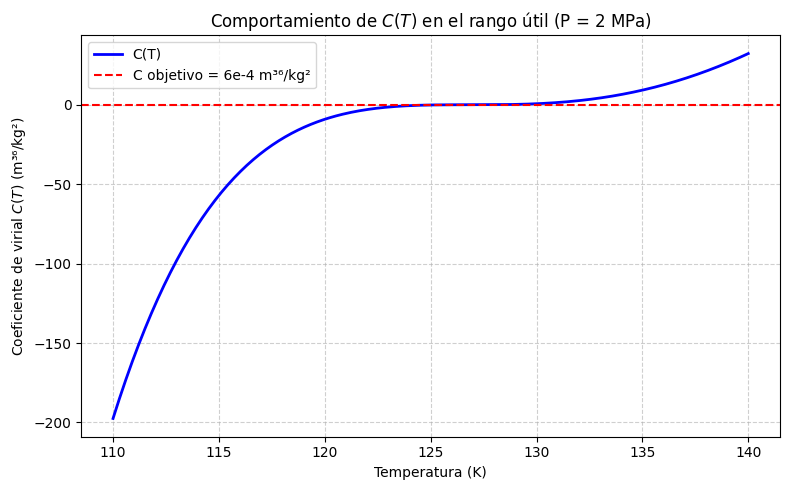

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Funciones ya definidas para V(T), B(T), Z(T) y C(T)
def v_T(T):
    return -5.333e-9 * T**4 + 6.4e-6 * T**3 - 0.0027667 * T**2 + 0.527 * T - 34

def B_T(T):
    return -0.199 + 0.2 * np.exp(-1131 / T**2)

def Z_T(P, v, T, M, R):
    return (P * v * M) / (R * T)

def C_T(T, P=2e6, M=0.01604, R=8.314):
    v = v_T(T)
    B = B_T(T)
    Z = Z_T(P, v, T, M, R)
    return (Z - 1 - B / v) * v**2

# Crear un rango de temperaturas donde está la raíz (~127 K)
T_range = np.linspace(110, 140, 300)
C_values = [C_T(T) for T in T_range]

# Graficar
plt.figure(figsize=(8, 5))
plt.plot(T_range, C_values, label="C(T)", color='blue', linewidth=2)
plt.axhline(6e-4, color='red', linestyle='--', label='C objetivo = 6e-4 m³⁶/kg²')
plt.xlabel("Temperatura (K)")
plt.ylabel("Coeficiente de virial $C(T)$ (m³⁶/kg²)")
plt.title("Comportamiento de $C(T)$ en el rango útil (P = 2 MPa)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


### e) Repetición del análisis para una presión de 2 MPa

En este apartado se ha repetido el mismo procedimiento desarrollado en el apartado **d)**, pero considerando una **presión de 2 MPa**.

El objetivo es encontrar la **temperatura $T$** que cumple:

$$
C(T) = 6 \times 10^{-4} \ \text{m}^6/\text{kg}^2
$$

usando el modelo:

$$
C(T) = \left( \frac{P V(T)}{R T} - 1 - \frac{B(T)}{V(T)} \right) V(T)^2
$$

donde:

- $V(T)$ es el volumen específico interpolado a partir de los datos del apartado b) (m³/kg)  
- $B(T)$ es el coeficiente de virial de segundo orden    
- $M = 0.01604 \, \text{kg/mol}$ es la masa molar del metano  
- $P = 2 \, \text{MPa} = 2 \times 10^6 \, \text{Pa}$

Se ha aplicado el **método de bisección** para resolver la ecuación $f(T) = C(T) - C_{\text{objetivo}} = 0$ bajo diferentes tolerancias.

---

#### Gráfico de $C(T)$ vs Temperatura

Se representa gráficamente el comportamiento del coeficiente de virial $C(T)$ para presiones de 2 MPa: 

La curva azul representa $C(T)$ y la línea roja discontinua indica el valor objetivo de $6 \times 10^{-4} \, \text{m}^6/\text{kg}^2$.


---

####  Conclusión del apartado e)

El comportamiento de $C(T)$ frente a la temperatura muestra una tendencia decreciente en este rango.  
La temperatura que satisface la condición requerida se encuentra nuevamente alrededor de los **127.1 K**, ligeramente menor que en el caso de 1 MPa.

La gráfica valida visualmente la convergencia de los resultados, y el método de bisección ha demostrado ser robusto en todos los niveles de tolerancia aplicados.


